<a href="https://colab.research.google.com/github/aabyyaann/Practical-Statistics-for-Data-Scientists/blob/main/Chapter07_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7 — Unsupervised Learning

## Tujuan Chapter

Pada chapter ini kita mempelajari Unsupervised Learning, yaitu teknik machine learning yang digunakan ketika data tidak memiliki label.

Topik yang dipelajari:

1. Unsupervised Learning
2. Clustering
3. Distance Metrics
4. K-Means Clustering
5. Elbow Method
6. Hierarchical Clustering
7. Dendrogram
8. Principal Component Analysis (PCA)
9. Dimensionality Reduction
10. Cluster Interpretation

Unsupervised Learning banyak digunakan dalam:

- Customer Segmentation
- Recommendation Systems
- Fraud Detection
- Data Compression
- Computer Vision

# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

np.random.seed(42)

# Dataset Contoh

Dataset pelanggan berdasarkan pendapatan dan pengeluaran.

In [2]:
customer = pd.DataFrame({
    "Income":[15,16,17,18,20,60,62,65,67,70],
    "Spending":[18,20,22,25,28,70,72,75,78,80]
})

customer

,Income,Spending
0,15,18
1,16,20
2,17,22
3,18,25
4,20,28
5,60,70
6,62,72
7,65,75
8,67,78
9,70,80


# Visualisasi Awal Data

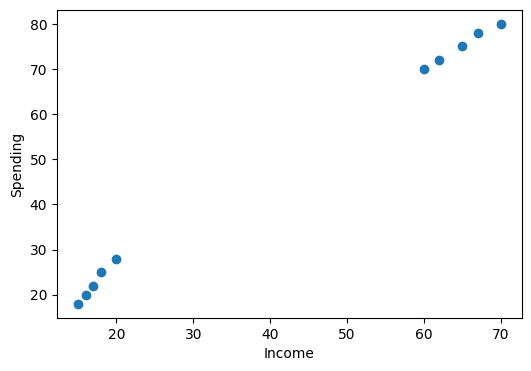

In [3]:
plt.figure(figsize=(6,4))

plt.scatter(
    customer["Income"],
    customer["Spending"]
)

plt.xlabel("Income")
plt.ylabel("Spending")

plt.show()

# 1. Unsupervised Learning

Berbeda dengan supervised learning, unsupervised learning tidak menggunakan label target.

Tujuannya adalah menemukan pola tersembunyi dalam data.

# 2. Clustering

Clustering bertujuan mengelompokkan data yang memiliki karakteristik mirip.

# 3. Distance Metrics

Sebagian besar algoritma clustering menggunakan jarak antar data.

Contoh:

- Euclidean Distance
- Manhattan Distance
- Cosine Distance

In [4]:
point_a = np.array([10,20])

point_b = np.array([15,30])

distance = np.linalg.norm(
    point_a - point_b
)

print(distance)

11.180339887498949


# Euclidean Distance

Merupakan jarak garis lurus antara dua titik.

# 4. K-Means Clustering

K-Means adalah algoritma clustering paling populer.

In [5]:
X = customer[
    ["Income","Spending"]
]

In [6]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

KMeans(n_clusters=2, n_init=10, random_state=42)

# Label Cluster

In [7]:
clusters = kmeans.labels_

clusters

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=int32)

In [8]:
customer["Cluster"] = clusters

customer

,Income,Spending,Cluster
0,15,18,0
1,16,20,0
2,17,22,0
3,18,25,0
4,20,28,0
5,60,70,1
6,62,72,1
7,65,75,1
8,67,78,1
9,70,80,1


# Visualisasi Hasil Clustering

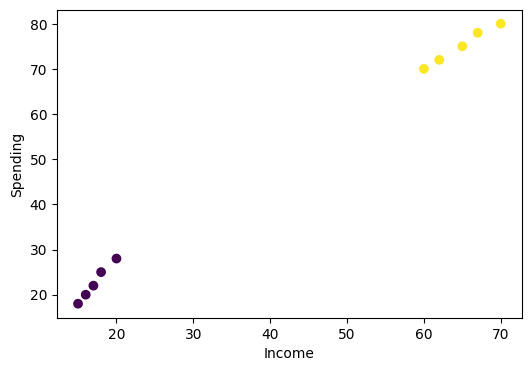

In [9]:
plt.figure(figsize=(6,4))

plt.scatter(
    customer["Income"],
    customer["Spending"],
    c=customer["Cluster"]
)

plt.xlabel("Income")
plt.ylabel("Spending")

plt.show()

# Centroid Cluster

In [10]:
kmeans.cluster_centers_

array([[17.2, 22.6],
       [64.8, 75. ]])

# Interpretasi

Centroid merupakan pusat dari setiap cluster.

# 5. Elbow Method

Digunakan untuk menentukan jumlah cluster terbaik.

In [11]:
inertia = []

for k in range(1,8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    inertia.append(
        model.inertia_
    )

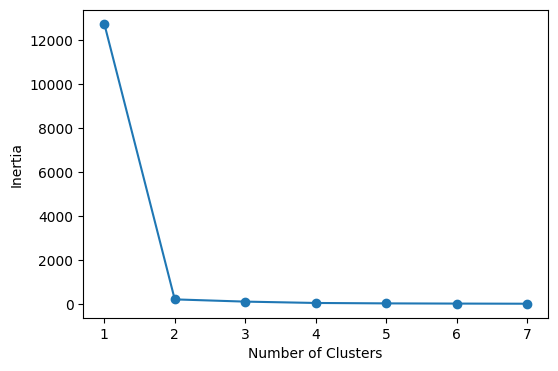

In [12]:
plt.figure(figsize=(6,4))

plt.plot(
    range(1,8),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

# Interpretasi Elbow Method

Titik siku (elbow) menunjukkan jumlah cluster yang optimal.

# 6. Hierarchical Clustering

Hierarchical Clustering membangun struktur cluster berbentuk pohon.

In [13]:
linked = linkage(
    X,
    method="ward"
)

# Dendrogram

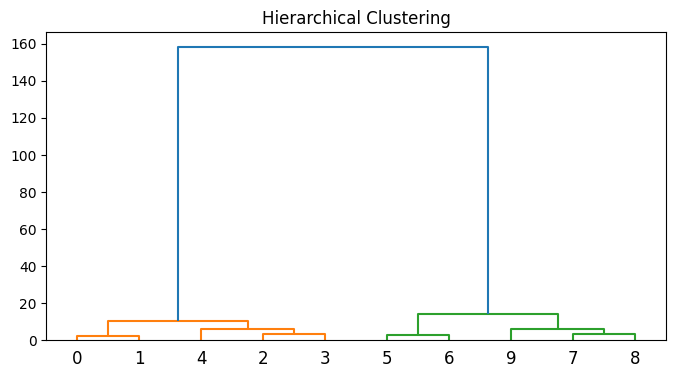

In [14]:
plt.figure(figsize=(8,4))

dendrogram(
    linked
)

plt.title(
    "Hierarchical Clustering"
)

plt.show()

# Interpretasi Dendrogram

Semakin rendah dua cabang bergabung, semakin mirip kedua data tersebut.

# 7. Principal Component Analysis (PCA)

PCA digunakan untuk mengurangi dimensi data.

In [15]:
pca = PCA(
    n_components=2
)

pca.fit(X)

PCA(n_components=2)

# Principal Components

In [16]:
print(
    pca.components_
)

[[ 0.67137053  0.74112186]
 [ 0.74112186 -0.67137053]]


# Explained Variance Ratio

In [17]:
print(
    pca.explained_variance_ratio_
)

[9.99462416e-01 5.37583945e-04]


# Interpretasi

Explained Variance menunjukkan berapa banyak informasi yang dipertahankan oleh setiap principal component.

# Transformasi PCA

In [18]:
X_pca = pca.transform(X)

X_pca[:5]

array([[-40.28218706,   1.40904416],
       [-38.12857282,   0.80742495],
       [-35.97495857,   0.20580574],
       [-33.08022246,  -1.06718401],
       [-29.51411583,  -1.59905189]])

# Visualisasi PCA

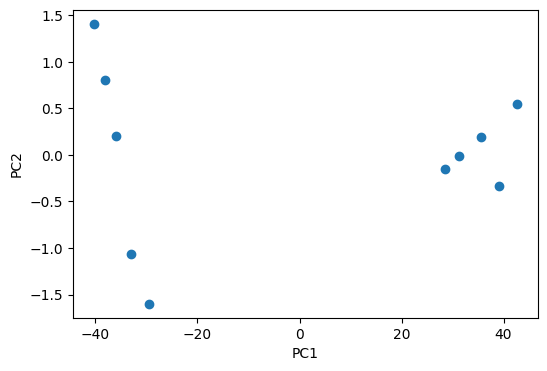

In [19]:
plt.figure(figsize=(6,4))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

# 8. Dimensionality Reduction

Dimensionality Reduction digunakan untuk:

- Mengurangi kompleksitas data
- Mempercepat training
- Mengurangi noise
- Membantu visualisasi

# 9. Cluster Interpretation

Setelah cluster terbentuk, langkah berikutnya adalah memahami karakteristik setiap cluster.

In [20]:
customer.groupby(
    "Cluster"
).mean()

,Income,Spending
Cluster,,
0,17.2,22.6
1,64.8,75.0


customer.groupby(
    "Cluster"
).mean()

# Perbandingan Metode

K-Means:
- Cepat
- Mudah digunakan

Hierarchical:
- Lebih mudah diinterpretasikan
- Cocok untuk dataset kecil

PCA:
- Reduksi dimensi
- Bukan algoritma clustering

# Aplikasi Dunia Nyata

- Customer Segmentation
- Market Basket Analysis
- Image Compression
- Recommendation Systems
- Fraud Detection

# Ringkasan Chapter 7

Pada chapter ini dipelajari:

- Unsupervised Learning
- Distance Metrics
- K-Means Clustering
- Elbow Method
- Hierarchical Clustering
- Dendrogram
- PCA
- Dimensionality Reduction
- Cluster Interpretation

Unsupervised Learning sangat berguna ketika data tidak memiliki label dan kita ingin menemukan pola tersembunyi dalam data.

# Ringkasan Buku

Practical Statistics for Data Scientists membahas:

Chapter 1:
- Exploratory Data Analysis

Chapter 2:
- Sampling and Distributions

Chapter 3:
- Statistical Experiments and Significance Testing

Chapter 4:
- Regression and Prediction

Chapter 5:
- Classification

Chapter 6:
- Statistical Machine Learning

Chapter 7:
- Unsupervised Learning

Materi-materi tersebut menjadi fondasi penting dalam Data Science, Machine Learning, dan Deep Learning.